# Chapter 8 — Linear least-squares problems

**Numerical Linear Algebra: Theory, Algorithms, and Computation**

**Abdallah Alsammani, Ph.D.**  
Department of Mathematical Sciences & Data Science  
Delaware State University

Lecture notes: <https://aalsammani.github.io/numerical-linear-algebra/>  
Notes for this chapter: <https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html>  
Repository: <https://github.com/aalsammani/Numerical-Linear-Algebra-Notebooks>

This notebook is the computational laboratory of the chapter; the theory,
proofs and exercises are in the lecture notes, to which the links below
point. References such as Trefethen and Bau (1997) are listed in the
[bibliography of the notes](https://aalsammani.github.io/numerical-linear-algebra/back/bibliography.html). Version
1.0, September 2026.

---

This notebook accompanies [Chapter 8](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08) of the notes. Every
experiment checks a statement from the chapter numerically.

**Learning objectives.** After working through this lab you should be able to

1. implement least squares by the normal equations with Cholesky, by
   Householder QR with $Q^Tb$ applied implicitly, and by the (truncated) SVD,
   and verify them against `numpy.linalg.lstsq` with justified tolerances;
2. measure the rounding error of an algorithm correctly, against the exact
   least-squares solution of the same data;
3. reproduce the dependence of the forward error on $\kappa(A)$ and on the
   size of the residual, and verify the condition numbers of
   [Theorem 8.3](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-thm-conditioning);
4. explain why modified Gram--Schmidt must process $b$ as an extra column;
5. compute minimum-norm solutions of rank-deficient problems and make rank
   decisions;
6. regularize a discrete ill-posed problem with Tikhonov regularization and
   choose the parameter with the L-curve.

Run the cells in order from a fresh kernel.

In [1]:
import time
from fractions import Fraction

import matplotlib.pyplot as plt
import numpy as np
import scipy.linalg as sla
import scipy.sparse as sp
import scipy.sparse.linalg as spla

rng = np.random.default_rng(20260808)
u = np.finfo(float).eps / 2          # unit roundoff of IEEE double precision, 2**-53
plt.rcParams.update({"figure.figsize": (6.4, 4.0), "axes.grid": True, "grid.alpha": 0.3})
print(f"NumPy {np.__version__}, SciPy {__import__('scipy').__version__}; u = {u:.3e}")

NumPy 2.5.3, SciPy 1.18.1; u = 1.110e-16


## 1. The worked example

We start with [Example 8.1](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-exa-line): fitting a line to $(0,1)$, $(1,2)$,
$(2,4)$. The exact solution is $x = (5/6, 3/2)^T$ and the residual is
$(1/6, -1/3, 1/6)^T$.

In [2]:
A = np.array([[1.0, 0.0], [1.0, 1.0], [1.0, 2.0]])
b = np.array([1.0, 2.0, 4.0])
x, res, rank, sv = np.linalg.lstsq(A, b, rcond=None)
r = b - A @ x
print("x =", x, " r =", r, " A^T r =", A.T @ r)
print(f"||r||_2 = {np.linalg.norm(r):.6f} (1/sqrt(6) = {1 / np.sqrt(6):.6f})")
# kappa(A) is about 3, so the computed x is correct to a small multiple of u.
assert np.allclose(x, [5 / 6, 3 / 2], rtol=0, atol=10 * u)
assert np.allclose(r, [1 / 6, -1 / 3, 1 / 6], rtol=0, atol=10 * u)

x = [0.83333333 1.5       ]  r = [ 0.16666667 -0.33333333  0.16666667]  A^T r = [6.66133815e-16 8.88178420e-16]
||r||_2 = 0.408248 (1/sqrt(6) = 0.408248)


## 2. Three solvers, implemented correctly

The legacy code for this course had docstrings that did not match the code:
a function documented as "normal equations via Cholesky" called
`np.linalg.solve` (an LU factorization), and a "minimum-norm" SVD solver
divided by all singular values, including zero ones. Here are correct
versions.

- `ls_normal` forms $A^TA$ and $A^Tb$ and uses a Cholesky factorization
  ([Algorithm 8.1](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-alg-normal)). It raises `LinAlgError` if the computed
  $A^TA$ is not positive definite.
- `ls_householder` implements [Algorithm 8.2](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-alg-householder): each reflector
  is applied to the remaining columns *and to $b$*, so $Q$ is never formed.
- `ls_svd` implements [Algorithm 8.3](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-alg-tsvd) with a relative tolerance: it
  returns the minimum-norm solution of the problem with the singular values
  below `rtol * sigma_1` set to zero.

In [3]:
def ls_normal(A, b):
    """Least squares by the normal equations A^T A x = A^T b, solved by Cholesky."""
    C = A.T @ A
    L = np.linalg.cholesky(C)                       # C = L L^T; LinAlgError if not SPD
    z = sla.solve_triangular(L, A.T @ b, lower=True)
    return sla.solve_triangular(L.T, z, lower=False)


def ls_householder(A, b):
    """Least squares by Householder QR; Q^T b is accumulated reflector by reflector."""
    R = np.array(A, dtype=float)
    c = np.array(b, dtype=float)
    m, n = R.shape
    for k in range(n):
        x = R[k:, k]
        s = 1.0 if x[0] >= 0 else -1.0             # sign choice avoids cancellation (Chapter 1)
        v = x.copy()
        v[0] += s * np.linalg.norm(x)
        v /= np.linalg.norm(v)                      # H = I - 2 v v^T with ||v|| = 1
        R[k:, k:] -= 2.0 * np.outer(v, v @ R[k:, k:])
        c[k:] -= 2.0 * v * (v @ c[k:])
    return sla.solve_triangular(np.triu(R[:n]), c[:n], lower=False)


def ls_svd(A, b, rtol=None):
    """Minimum-norm least-squares solution with singular values <= rtol*sigma_1 treated as zero.

    The default rtol = max(m, n) * eps is the default of numpy.linalg.lstsq.
    """
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    if rtol is None:
        rtol = max(A.shape) * np.finfo(float).eps
    k = int(np.sum(s > rtol * s[0])) if s.size and s[0] > 0 else 0
    return Vt[:k].T @ ((U[:, :k].T @ b) / s[:k])

**Verification.** For a random, well-conditioned problem all three solvers
must agree with `numpy.linalg.lstsq`. How close? By
[(8.11)](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#equation-ch08-eq-qr-forward), a backward stable method has a relative error of
order $u(\kappa + \kappa^2\tan\theta/\eta)$ up to modest dimension-dependent
factors, and the normal equations of order $u\kappa^2$. We allow a factor
$10\,n$ on top of these, and compute $\kappa$, $\theta$ and $\eta$ from the
problem itself.

In [4]:
def kappa_theta_eta(A, b):
    x = np.linalg.lstsq(A, b, rcond=None)[0]
    y = A @ x
    kappa = np.linalg.cond(A)
    theta = np.arccos(min(1.0, np.linalg.norm(y) / np.linalg.norm(b)))
    eta = np.linalg.norm(A, 2) * np.linalg.norm(x) / np.linalg.norm(y)
    return kappa, theta, eta


m, n = 100, 12
A = rng.standard_normal((m, n))
b = rng.standard_normal(m)
kappa, theta, eta = kappa_theta_eta(A, b)
x_ref = np.linalg.lstsq(A, b, rcond=None)[0]
print(f"kappa = {kappa:.2f}, theta = {np.degrees(theta):.1f} degrees, eta = {eta:.2f}")
tol_stable = 10 * n * u * (kappa + kappa**2 * np.tan(theta) / eta + kappa / (eta * np.cos(theta)))
tol_normal = 10 * n * u * kappa**2 * (1 + 1 / (eta * np.cos(theta)))
for f, tol in ((ls_normal, tol_normal), (ls_householder, tol_stable), (ls_svd, tol_stable)):
    err = np.linalg.norm(f(A, b) - x_ref) / np.linalg.norm(x_ref)
    print(f"{f.__name__:15s} relative difference from lstsq {err:.1e}   (tolerance {tol:.1e})")
    assert err < tol

kappa = 1.77, theta = 65.6 degrees, eta = 1.32
ls_normal       relative difference from lstsq 7.1e-16   (tolerance 1.2e-13)
ls_householder  relative difference from lstsq 7.5e-16   (tolerance 1.4e-13)
ls_svd          relative difference from lstsq 9.5e-16   (tolerance 1.4e-13)


## 3. Measuring rounding errors correctly

To see the rounding errors of an algorithm we need the *exact* least-squares
solution of the data that the algorithm actually receives, which are
floating-point numbers. Every double is a rational number, so we can form and
solve the normal equations in exact rational arithmetic with Python's
`fractions` module and round only the final result. For $n\le10$ this takes a
few milliseconds.

In [5]:
def exact_lstsq(A, b):
    """Exact least-squares solution of the stored binary64 data, rounded to double at the end."""
    m, n = A.shape
    F = [[Fraction(v) for v in row] for row in A.tolist()]
    fb = [Fraction(v) for v in b.tolist()]
    M = [[sum(F[k][i] * F[k][j] for k in range(m)) for j in range(n)] for i in range(n)]
    c = [sum(F[k][i] * fb[k] for k in range(m)) for i in range(n)]
    for j in range(n):                              # Gaussian elimination: exact, no pivoting needed
        for i in range(j + 1, n):
            lij = M[i][j] / M[j][j]
            for k in range(j, n):
                M[i][k] -= lij * M[j][k]
            c[i] -= lij * c[j]
    x = [Fraction(0)] * n
    for i in reversed(range(n)):
        x[i] = (c[i] - sum(M[i][k] * x[k] for k in range(i + 1, n))) / M[i][i]
    return np.array([float(v) for v in x])


x_exact = exact_lstsq(A, b)
print(f"lstsq vs exact: {np.linalg.norm(x_ref - x_exact) / np.linalg.norm(x_exact):.1e}")

lstsq vs exact: 6.9e-16


**The legacy comparison, redone.** The legacy notebook compared the normal
equations with QR for $m = 40$, $n = 8$, $\kappa = 10^7$, with data
$b = Ax_{\rm gen} + e$ and noise $e$ of size $10^{-8}$, and it measured both
errors against $x_{\rm gen}$. It reported no significant difference. We build
a matrix with singular values $1,\dots,10^{-7}$ as $A = U\Sigma V^T$ with
random orthonormal factors and repeat the experiment with our own random
data.

In [6]:
def matrix_with_singular_values(m, sigma, rng):
    """A = U diag(sigma) V^T with random U (m x n, orthonormal columns) and random orthogonal V."""
    n = len(sigma)
    U, _ = np.linalg.qr(rng.standard_normal((m, n)))
    V, _ = np.linalg.qr(rng.standard_normal((n, n)))
    return (U * sigma) @ V.T


m, n = 40, 8
A = matrix_with_singular_values(m, np.logspace(0, -7, n), rng)
x_gen = rng.standard_normal(n)
b = A @ x_gen + 1e-8 * rng.standard_normal(m)
x_ls = exact_lstsq(A, b)
print(f"kappa(A) = {np.linalg.cond(A):.2e}")
print(f"exact LS solution vs x_gen: {np.linalg.norm(x_ls - x_gen) / np.linalg.norm(x_gen):.1e}  (statistical error A^+ e)")
legacy = {}
for f in (ls_normal, ls_householder):
    xh = f(A, b)
    legacy[f.__name__] = (np.linalg.norm(xh - x_gen) / np.linalg.norm(x_gen), np.linalg.norm(xh - x_ls) / np.linalg.norm(x_ls))
    print(f"{f.__name__:15s} error vs x_gen {legacy[f.__name__][0]:.1e}   error vs exact LS solution {legacy[f.__name__][1]:.1e}")

kappa(A) = 1.00e+07
exact LS solution vs x_gen: 1.8e-02  (statistical error A^+ e)
ls_normal       error vs x_gen 2.9e-02   error vs exact LS solution 1.2e-02
ls_householder  error vs x_gen 1.8e-02   error vs exact LS solution 1.2e-10


Measured against $x_{\rm gen}$, both methods have an error of about
$10^{-2}$, because the least-squares solution itself differs from
$x_{\rm gen}$ by $A^+e$, whose largest term $(u_n^Te/\sigma_n)\,v_n$ has a
norm of order $10^{-8}/10^{-7} = 10^{-1}$.
That statistical error has nothing to do with the algorithm. Measured against
the exact least-squares solution of the same data, the normal equations have
a relative error of order $10^{-2}$ and Householder QR of order $10^{-10}$,
consistent with $u\kappa^2\approx10^{-2}$ and $u\kappa\approx10^{-9}$. (With
other random data the error of the normal equations varies between about
$10^{-4}$ and $10^{-2}$; the notes quote one such run.)

## 4. Forward error versus $\kappa$ and the size of the residual

We now reproduce [Figure 8.2](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-fig-accuracy). For each $\kappa$ we build $A$
with singular values logarithmically spaced between $1$ and $1/\kappa$, and
$b = Ax + t\,\|Ax\|_2\,q$ with $q$ a unit vector orthogonal to $\operatorname{range}(A)$,
so that $\tan\theta = t$.

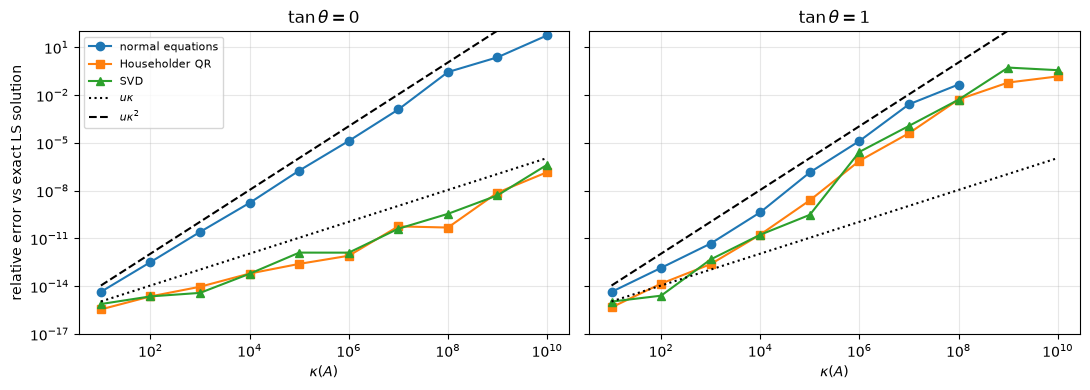

kappa = 1e6, zero residual:  NE 1.3e-05, QR 8.2e-13
kappa = 1e6, tan(theta) = 1: NE 1.3e-05, QR 7.4e-07


In [7]:
def make_problem(m, n, kappa, tan_theta, rng):
    Q, _ = np.linalg.qr(rng.standard_normal((m, n + 1)))
    V, _ = np.linalg.qr(rng.standard_normal((n, n)))
    A = (Q[:, :n] * np.logspace(0, -np.log10(kappa), n)) @ V.T
    y = A @ rng.standard_normal(n)
    return A, y + tan_theta * np.linalg.norm(y) * Q[:, n]


def rel_error(f, A, b, x):
    try:
        return np.linalg.norm(f(A, b) - x) / np.linalg.norm(x)
    except np.linalg.LinAlgError:
        return np.nan                                # Cholesky of fl(A^T A) broke down


kappas = 10.0 ** np.arange(1, 10.1, 1)
solvers = {"normal equations": ls_normal, "Householder QR": ls_householder, "SVD": ls_svd}
errors = {}
for tan_theta in (0.0, 1.0):
    errors[tan_theta] = {name: [] for name in solvers}
    for kappa in kappas:
        A, b = make_problem(40, 8, kappa, tan_theta, rng)
        x = exact_lstsq(A, b)
        for name, f in solvers.items():
            errors[tan_theta][name].append(rel_error(f, A, b, x))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, tan_theta in zip(axes, (0.0, 1.0)):
    for (name, errs), mk in zip(errors[tan_theta].items(), "os^"):
        ax.loglog(kappas, np.maximum(errs, 1e-17), marker=mk, label=name)
    ax.loglog(kappas, u * kappas, "k:", label=r"$u\kappa$")
    ax.loglog(kappas, u * kappas**2, "k--", label=r"$u\kappa^2$")
    ax.set_ylim(1e-17, 1e2)
    ax.set_xlabel(r"$\kappa(A)$")
    ax.set_title(rf"$\tan\theta = {tan_theta:g}$")
axes[0].set_ylabel("relative error vs exact LS solution")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Checks, with generous factors (40 x 8 problems; one random sample per kappa):
e0 = errors[0.0]
for i, kappa in enumerate(kappas):
    assert e0["Householder QR"][i] < 1e3 * kappa * u            # backward stable: O(kappa u) for zero residual
    assert e0["SVD"][i] < 1e3 * kappa * u
    if not np.isnan(e0["normal equations"][i]):
        assert e0["normal equations"][i] < 1e3 * kappa**2 * u    # O(kappa^2 u) whatever the residual
i6 = list(kappas).index(1e6)
print(f"kappa = 1e6, zero residual:  NE {e0['normal equations'][i6]:.1e}, QR {e0['Householder QR'][i6]:.1e}")
print(f"kappa = 1e6, tan(theta) = 1: NE {errors[1.0]['normal equations'][i6]:.1e}, "
      f"QR {errors[1.0]['Householder QR'][i6]:.1e}")

**Interpretation.** For a zero residual (left), QR and the SVD track
$u\kappa$ and the normal equations track $u\kappa^2$; beyond
$\kappa\approx10^8$ the Cholesky factorization of the computed $A^TA$ can fail
(missing points). For a large residual (right), the errors of all three
methods grow like $u\kappa^2$: the factor $\kappa^2\tan\theta/\eta$ in the condition number is
a property of the problem, and no algorithm can avoid it. The normal
equations are then of the same order of accuracy as QR, although in a single
run their error can still be larger by a modest factor (compare the two
errors printed for $\kappa = 10^6$).

## 5. Verifying the condition numbers

[Theorem 8.3](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-thm-conditioning) says that $\kappa_b = \kappa/(\eta\cos\theta)$
exactly, and that $\kappa_A$ lies between $\max\{\kappa,
\kappa^2\tan\theta/\eta\}$ and their sum. Its proof constructs the
perturbations that attain each term. We apply them with a small relative size
$\epsilon$ and measure the amplification $(\|\delta x\|_2/\|x\|_2)/\epsilon$.
We also try random perturbations, which typically amplify much less.

In [8]:
m, n = 30, 6
A, b = make_problem(m, n, 1e3, 0.5, rng)
U, s, Vt = np.linalg.svd(A, full_matrices=False)
x = np.linalg.lstsq(A, b, rcond=None)[0]
r = b - A @ x
kappa, theta, eta = kappa_theta_eta(A, b)
nA, nx, nb = s[0], np.linalg.norm(x), np.linalg.norm(b)
print(f"kappa = {kappa:.1f}, tan(theta) = {np.tan(theta):.3f}, eta = {eta:.2f}")
print(f"kappa_b = kappa/(eta cos theta) = {kappa / (eta * np.cos(theta)):.1f}")
print(f"kappa^2 tan(theta)/eta = {kappa**2 * np.tan(theta) / eta:.1f}")

eps = 1e-9
def amplification(dA, db):
    xp = np.linalg.lstsq(A + dA, b + db, rcond=None)[0]
    rel_data = max(np.linalg.norm(dA, 2) / nA, np.linalg.norm(db) / nb)
    return (np.linalg.norm(xp - x) / nx) / rel_data

tests = {
    "db = eps ||b|| u_n":             (np.zeros_like(A), eps * nb * U[:, -1]),
    "dA = eps ||A|| u_n x^T/||x||":   (eps * nA * np.outer(U[:, -1], x) / nx, np.zeros(m)),
    "dA = eps ||A|| r v_n^T/||r||":   (eps * nA * np.outer(r, Vt[-1]) / np.linalg.norm(r), np.zeros(m)),
}
predicted = [kappa / (eta * np.cos(theta)), kappa, kappa**2 * np.tan(theta) / eta]
for (name, (dA, db)), pred in zip(tests.items(), predicted):
    amp = amplification(dA, db)
    print(f"{name:32s} amplification {amp:10.1f}   predicted {pred:10.1f}")
    # First-order theory; second-order terms are O(eps kappa^2) ~ 1e-3 relative, rounding O(kappa u / eps).
    assert abs(amp / pred - 1) < 1e-2

rand_amp = []
for _ in range(200):
    dA = rng.standard_normal((m, n))
    dA *= eps * nA / np.linalg.norm(dA, 2)
    rand_amp.append(amplification(dA, np.zeros(m)))
bound = kappa + kappa**2 * np.tan(theta) / eta
print(f"random dA: median amplification {np.median(rand_amp):.1f}, max {max(rand_amp):.1f}, bound {bound:.1f}")
assert max(rand_amp) <= bound * (1 + 1e-2)

kappa = 1000.0, tan(theta) = 0.500, eta = 2.24
kappa_b = kappa/(eta cos theta) = 499.8
kappa^2 tan(theta)/eta = 223508.9
db = eps ||b|| u_n               amplification      499.8   predicted      499.8
dA = eps ||A|| u_n x^T/||x||     amplification     1000.0   predicted     1000.0
dA = eps ||A|| r v_n^T/||r||     amplification   223508.9   predicted   223508.9
random dA: median amplification 20772.8, max 92719.7, bound 224508.9


The special perturbations attain the predicted amplifications to about three
digits; random perturbations stay below the bound, typically well below it.
Note that we perturbed the *data* here and solved each perturbed problem
with the same backward stable method: these numbers describe the problem,
and any other accurate method would give the same.

## 6. Modified Gram--Schmidt: the right-hand side matters

MGS loses orthogonality in proportion to $\kappa u$
([Chapter 7](https://aalsammani.github.io/numerical-linear-algebra/ch07-qr/notes.html#ch07)). We compare two ways of using it for least
squares: forming $\hat Q^Tb$ with the computed $\hat Q$, and running MGS on
the augmented matrix $[A,\ b]$ ([Section 8.4](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-sec-stability)).

In [9]:
def mgs(A):
    """Modified Gram-Schmidt: A = Q R with Q (m x n) and R (n x n) upper triangular."""
    Q = np.array(A, dtype=float)
    m, n = Q.shape
    R = np.zeros((n, n))
    for k in range(n):
        R[k, k] = np.linalg.norm(Q[:, k])
        Q[:, k] /= R[k, k]
        R[k, k + 1:] = Q[:, k] @ Q[:, k + 1:]
        Q[:, k + 1:] -= np.outer(Q[:, k], R[k, k + 1:])
    return Q, R


def ls_mgs_explicit(A, b):
    """Unsafe: uses the computed Q, which may be far from orthogonal."""
    Q, R = mgs(A)
    return sla.solve_triangular(R, Q.T @ b)


def ls_mgs_augmented(A, b):
    """Backward stable: MGS on [A, b]; the last column of R is z, and R_1 x = z."""
    n = A.shape[1]
    _, R = mgs(np.column_stack([A, b]))
    return sla.solve_triangular(R[:n, :n], R[:n, n])


print(" kappa    ||Q^TQ-I||  MGS explicit  MGS augmented  Householder")
mgs_rows = []
for kappa in (1e2, 1e4, 1e6, 1e8, 1e10):
    A, b = make_problem(40, 8, kappa, 0.0, rng)
    x = exact_lstsq(A, b)
    Q, _ = mgs(A)
    row = [np.linalg.norm(Q.T @ Q - np.eye(8), 2)] + [rel_error(f, A, b, x) for f in
                                                      (ls_mgs_explicit, ls_mgs_augmented, ls_householder)]
    mgs_rows.append(row)
    print(f"{kappa:6.0e}   {row[0]:9.1e}   {row[1]:11.1e}   {row[2]:12.1e}   {row[3]:10.1e}")
    assert row[2] < 1e3 * kappa * u               # augmented MGS: O(kappa u), like Householder

 kappa    ||Q^TQ-I||  MGS explicit  MGS augmented  Householder
 1e+02     4.0e-15       5.4e-14        1.1e-15      1.6e-15
 1e+04     2.8e-13       6.4e-10        3.3e-14      6.0e-14
 1e+06     6.5e-11       3.8e-05        1.9e-12      5.3e-12
 1e+08     3.7e-09       1.4e-01        2.7e-10      9.2e-10
 1e+10     7.5e-07       3.4e+03        2.1e-08      4.5e-09


The explicit variant loses accuracy like the normal equations, in proportion
to $\kappa^2u$, while MGS on $[A,\ b]$ is as accurate as Householder QR, even
when $\hat Q$ is far from orthogonal. The least-squares solution does not
need an orthogonal $\hat Q$; it needs the right-hand side to be transformed by
the same sequence of operations as the columns of $A$.

What about `numpy.linalg.qr`, which forms the Householder $Q$ explicitly?
Its $Q$ is orthogonal to working accuracy, so $x = R^{-1}(Q^Tb)$ is fine.

In [10]:
def ls_numpy_qr(A, b):
    Q, R = np.linalg.qr(A)
    return sla.solve_triangular(R, Q.T @ b)


for kappa in (1e4, 1e8):
    A, b = make_problem(40, 8, kappa, 0.0, rng)
    x = exact_lstsq(A, b)
    e_np, e_hh = rel_error(ls_numpy_qr, A, b, x), rel_error(ls_householder, A, b, x)
    print(f"kappa = {kappa:.0e}: numpy.linalg.qr {e_np:.1e}, implicit Householder {e_hh:.1e}")
    assert e_np < 1e3 * kappa * u

kappa = 1e+04: numpy.linalg.qr 9.6e-14, implicit Householder 4.8e-14
kappa = 1e+08: numpy.linalg.qr 2.4e-10, implicit Householder 1.1e-10


## 7. The Läuchli matrix: when the normal equations lose everything

For $A = \begin{bmatrix}1&1\\\epsilon&0\\0&\epsilon\end{bmatrix}$ with
$\epsilon = 10^{-8}$, the exact $A^TA$ has diagonal entries $1+\epsilon^2$,
but $\epsilon^2 = 10^{-16}<u$, so the computed $A^TA$ is exactly the singular
matrix of all ones ([Exercise 8.5](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-ex-lauchli)).

In [11]:
eps_l = 1e-8
A = np.array([[1.0, 1.0], [eps_l, 0.0], [0.0, eps_l]])
b = np.array([2.0, eps_l, eps_l])                  # b = A (1, 1)^T: zero residual
print("fl(A^T A) =\n", A.T @ A)
print(f"kappa(A) = {np.linalg.cond(A):.3e}")
try:
    ls_normal(A, b)
    print("Cholesky succeeded")
except np.linalg.LinAlgError as err:
    print("normal equations: Cholesky failed:", err)
x_qr = ls_householder(A, b)
err_qr = np.linalg.norm(x_qr - 1) / np.sqrt(2)
print(f"Householder QR: x = {x_qr}, relative error {err_qr:.1e}")
assert err_qr < 100 * np.linalg.cond(A) * u      # O(kappa u) for a consistent problem

fl(A^T A) =
 [[1. 1.]
 [1. 1.]]
kappa(A) = 1.414e+08
normal equations: Cholesky failed: Matrix is not positive definite
Householder QR: x = [1. 1.], relative error 0.0e+00


## 8. Cost: flops and one machine's timings

The normal equations cost about $mn^2 + n^3/3$ flops and Householder QR about
$2mn^2 - 2n^3/3$ ([Section 8.2](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-sec-methods)). We time LAPACK-based versions
(`scipy.linalg.cho_factor` on $A^TA$, `scipy.linalg.qr` in `"economic"` mode
with a triangular solve, and `numpy.linalg.lstsq`), taking the median of
several repeats. The absolute numbers are observations on the machine that
executed this notebook.

In [12]:
def median_time(f, *args, repeats=7):
    f(*args)
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        f(*args)
        times.append(time.perf_counter() - t0)
    return float(np.median(times))


def ne_lapack(A, b):
    return sla.cho_solve(sla.cho_factor(A.T @ A), A.T @ b)


def qr_lapack(A, b):
    Q, R = sla.qr(A, mode="economic")
    return sla.solve_triangular(R, Q.T @ b)


m, n = 4000, 200
A = rng.standard_normal((m, n))
b = rng.standard_normal(m)
for name, f in (("normal equations", ne_lapack), ("QR (economic)", qr_lapack),
                ("lstsq (SVD-based)", lambda A, b: np.linalg.lstsq(A, b, rcond=None)[0])):
    print(f"{name:18s} {1e3 * median_time(f, A, b):7.1f} ms")
print(f"flop ratio QR / normal equations predicted by the leading terms: "
      f"{(2 * m * n**2 - 2 * n**3 / 3) / (m * n**2 + n**3 / 3):.2f}")

normal equations       2.3 ms


QR (economic)        150.3 ms


lstsq (SVD-based)     47.7 ms
flop ratio QR / normal equations predicted by the leading terms: 1.93


The measured ratios need not match the flop ratio: forming $A^TA$ is a
single level-3 BLAS operation that runs very fast, while the QR factorization
and especially the formation of the explicit $Q$ are organized differently
([Chapter 1](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01)).

## 9. Rank-deficient problems and the minimum-norm solution

The legacy "minimum-norm" SVD solver divided by every singular value. For a
matrix of exact rank $3$, the computed singular values $\sigma_4,\dots$ are
of order $u\sigma_1$ rather than zero, and dividing by them produces an
enormous vector.

In [13]:
def ls_svd_legacy(A, b):
    """The legacy code: no truncation (do not use)."""
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    return Vt.T @ ((U.T @ b) / s)


m, n, k = 20, 6, 3
A = rng.standard_normal((m, k)) @ rng.standard_normal((k, n))      # rank 3
b = rng.standard_normal(m)
s = np.linalg.svd(A, compute_uv=False)
print("singular values:", np.array2string(s, precision=2))
x_leg = ls_svd_legacy(A, b)
x_min = ls_svd(A, b)
x_np = np.linalg.lstsq(A, b, rcond=None)[0]
x_pinv = np.linalg.pinv(A) @ b
print(f"||x|| legacy (no truncation) = {np.linalg.norm(x_leg):.2e}")
print(f"||x|| truncated SVD          = {np.linalg.norm(x_min):.4f}")
print(f"residuals: legacy {np.linalg.norm(b - A @ x_leg):.4f}, truncated {np.linalg.norm(b - A @ x_min):.4f}")
# The truncated solution is the minimum-norm solution: it agrees with lstsq and pinv to
# O(kappa_k u), kappa_k = sigma_1/sigma_3, and it lies in range(A^T) (orthogonal to null(A)).
kappa_k = s[0] / s[k - 1]
assert np.linalg.norm(x_min - x_np) < 100 * kappa_k * u * np.linalg.norm(x_min)
assert np.linalg.norm(x_min - x_pinv) < 100 * kappa_k * u * np.linalg.norm(x_min)
Vt = np.linalg.svd(A)[2]
print(f"component of x_min in null(A): {np.linalg.norm(Vt[k:] @ x_min):.1e}")

singular values: [1.80e+01 1.02e+01 8.65e+00 2.08e-15 1.11e-15 4.71e-16]
||x|| legacy (no truncation) = 3.65e+15
||x|| truncated SVD          = 0.0777
residuals: legacy 5.8287, truncated 2.9244
component of x_min in null(A): 2.5e-17


The legacy solution has a huge norm and even a larger residual than the
truncated one: it is dominated by rounding noise divided by
$\sigma_4,\dots,\sigma_6\approx10^{-16}$. With an exactly zero singular value
it would contain `inf` or `nan`.

**Basic versus minimum-norm solutions.** QR with column pivoting
(`scipy.linalg.qr(A, pivoting=True)`) reveals the rank through the diagonal of
$R$, and gives a *basic* solution with only $k$ nonzero entries. It solves
the least-squares problem equally well but is not the minimum-norm solution.
`scipy.linalg.lstsq` with the driver `gelsy` uses a complete orthogonal
factorization and returns the minimum-norm solution.

In [14]:
Q, R, perm = sla.qr(A, pivoting=True, mode="economic")
print("|diag(R)| =", np.array2string(np.abs(np.diag(R)), precision=2))
k_qr = int(np.sum(np.abs(np.diag(R)) > max(A.shape) * np.finfo(float).eps * abs(R[0, 0])))
c = Q.T @ b
x_basic = np.zeros(n)
x_basic[perm[:k_qr]] = sla.solve_triangular(R[:k_qr, :k_qr], c[:k_qr])
x_gelsy = sla.lstsq(A, b, lapack_driver="gelsy")[0]
print(f"numerical rank from pivoted QR: {k_qr}")
print(f"basic solution:    ||x|| = {np.linalg.norm(x_basic):.4f}, residual {np.linalg.norm(b - A @ x_basic):.6f}, "
      f"nonzeros {np.count_nonzero(x_basic)}")
print(f"gelsy (min-norm):  ||x|| = {np.linalg.norm(x_gelsy):.4f}, residual {np.linalg.norm(b - A @ x_gelsy):.6f}")
assert k_qr == k
assert np.linalg.norm(x_gelsy - x_min) < 100 * kappa_k * u * np.linalg.norm(x_min)
assert np.linalg.norm(x_basic) >= np.linalg.norm(x_min) * (1 - 1e-12)

|diag(R)| = [1.27e+01 6.52e+00 5.27e+00 4.26e-15 9.32e-16 7.09e-16]
numerical rank from pivoted QR: 3
basic solution:    ||x|| = 0.1449, residual 2.924378, nonzeros 3
gelsy (min-norm):  ||x|| = 0.0777, residual 2.924378


**Rank decisions with noisy data.** Now perturb the rank-3 matrix by noise
of size $10^{-6}$. The matrix has full rank in exact arithmetic, but three of
its singular values are at the noise level. `numpy.linalg.lstsq` with the
default cutoff treats the problem as full rank, and the solution is
dominated by the noise directions; a cutoff chosen from the noise level
recovers a stable solution ([Exercise 8.12](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-ex-rank)).

In [15]:
A_noisy = A + 1e-6 * rng.standard_normal(A.shape)
s_noisy = np.linalg.svd(A_noisy, compute_uv=False)
print("singular values:", np.array2string(s_noisy, precision=2))
for rcond in (None, 1e-4):
    x_r, _, rank_r, _ = np.linalg.lstsq(A_noisy, b, rcond=rcond)
    print(f"rcond = {rcond}: rank {rank_r}, ||x|| = {np.linalg.norm(x_r):.3e}, "
          f"||x - x_min|| / ||x_min|| = {np.linalg.norm(x_r - x_min) / np.linalg.norm(x_min):.1e}")

singular values: [1.80e+01 1.02e+01 8.65e+00 4.32e-06 4.05e-06 2.36e-06]
rcond = None: rank 6, ||x|| = 4.048e+05, ||x - x_min|| / ||x_min|| = 5.2e+06
rcond = 0.0001: rank 3, ||x|| = 7.770e-02, ||x - x_min|| / ||x_min|| = 4.5e-07


The perturbation of size about $10^{-6}$ changes the default solution by a
relative amount of order $10^6$, as [Proposition 8.1](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-prop-discontinuity) predicts, while
the truncated solution changes only by an amount of the order of the noise.

## 10. Tikhonov regularization of a discrete ill-posed problem

We discretize the blurring operator $(Kx)(s) = \int_0^1 k(s,t)x(t)\,dt$ with a
Gaussian kernel $k(s,t) = \exp(-(s-t)^2/(2w^2))/(w\sqrt{2\pi})$, $w = 0.05$,
by the midpoint rule with $n = 64$ points, choose a true solution with a box
and a triangle, and add Gaussian noise of relative size $10^{-3}$. This is the
problem of [Figure 8.3](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-fig-tikhonov).

sigma_1 = 0.989, sigma_n = 4.8e-17, computed kappa(K) = 8.1e+17
relative error of the naive solution K^(-1) b: 5.2e+13


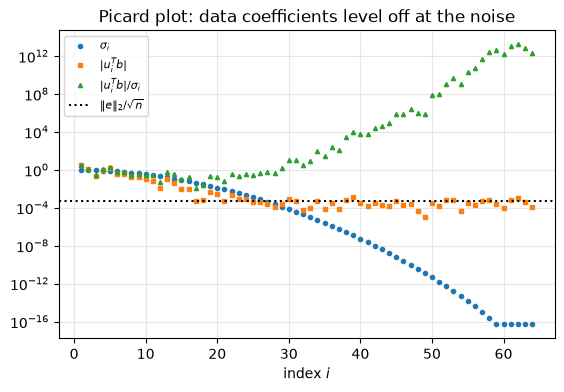

In [16]:
def fredholm_problem(n=64, width=0.05, noise=1e-3, seed=2026):
    g = np.random.default_rng(seed)
    s = (np.arange(n) + 0.5) / n
    K = np.exp(-((s[:, None] - s[None, :]) ** 2) / (2 * width**2)) / (width * np.sqrt(2 * np.pi) * n)
    x_true = ((s > 0.2) & (s < 0.45)).astype(float) + 0.8 * np.maximum(0.0, 1 - np.abs(s - 0.72) / 0.12)
    b_exact = K @ x_true
    e = g.standard_normal(n)
    e *= noise * np.linalg.norm(b_exact) / np.linalg.norm(e)
    return s, K, x_true, b_exact + e, e


s_grid, K, x_true, b, e = fredholm_problem()
U, sig, Vt = np.linalg.svd(K)
beta = U.T @ b
relerr = lambda x: np.linalg.norm(x - x_true) / np.linalg.norm(x_true)
print(f"sigma_1 = {sig[0]:.3f}, sigma_n = {sig[-1]:.1e}, computed kappa(K) = {np.linalg.cond(K):.1e}")
print(f"relative error of the naive solution K^(-1) b: {relerr(np.linalg.solve(K, b)):.1e}")

fig, ax = plt.subplots()
ax.semilogy(np.arange(1, 65), sig, "o", ms=3, label=r"$\sigma_i$")
ax.semilogy(np.arange(1, 65), np.abs(beta), "s", ms=3, label=r"$|u_i^Tb|$")
ax.semilogy(np.arange(1, 65), np.abs(beta) / sig, "^", ms=3, label=r"$|u_i^Tb|/\sigma_i$")
ax.axhline(np.linalg.norm(e) / 8, color="k", ls=":", label=r"$\|e\|_2/\sqrt{n}$")
ax.set_xlabel("index $i$")
ax.set_title("Picard plot: data coefficients level off at the noise")
ax.legend(fontsize=8)
plt.show()

The coefficients $|u_i^Tb|$ decay with $\sigma_i$ until they reach the noise
level, after which they stay roughly constant while $\sigma_i$ keeps
decreasing; the quotients $|u_i^Tb|/\sigma_i$, which are the coefficients of
the naive solution, grow enormously.

**Truncated SVD and Tikhonov.** Both are filters applied to the terms of
[(8.13)](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#equation-ch08-eq-min-norm): the truncated SVD uses factors $1$ and $0$, Tikhonov
uses $f_i = \sigma_i^2/(\sigma_i^2+\lambda^2)$.

TSVD: best k = 23, relative error 0.162


lambda = 0.001: kappa([K; lam I]) = 9.9e+02, augmented QR vs SVD formula: 2.6e-13


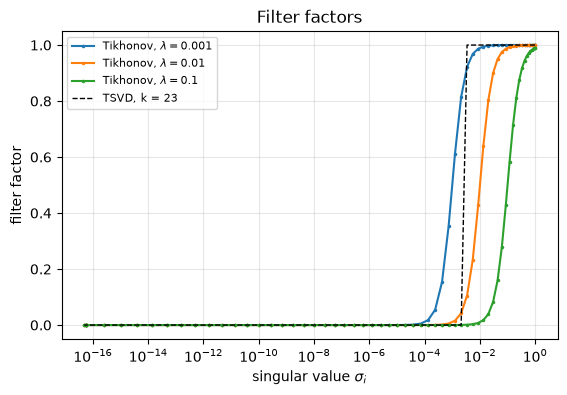

In [17]:
def tikhonov_svd(lam):
    f = sig**2 / (sig**2 + lam**2)
    return Vt.T @ (f * beta / sig)


def tikhonov_augmented(lam):
    """Stable computation: ordinary least squares with the stacked matrix [K; lam I]."""
    n = K.shape[1]
    return ls_householder(np.vstack([K, lam * np.eye(n)]), np.concatenate([b, np.zeros(n)]))


tsvd_err = [relerr(Vt[:k].T @ (beta[:k] / sig[:k])) for k in range(1, 65)]
k_best = int(np.argmin(tsvd_err)) + 1
print(f"TSVD: best k = {k_best}, relative error {min(tsvd_err):.3f}")

lam = 1e-3
x_a, x_s = tikhonov_augmented(lam), tikhonov_svd(lam)
kappa_aug = np.sqrt((sig[0]**2 + lam**2) / (sig[-1]**2 + lam**2))
print(f"lambda = {lam}: kappa([K; lam I]) = {kappa_aug:.1e}, "
      f"augmented QR vs SVD formula: {np.linalg.norm(x_a - x_s) / np.linalg.norm(x_s):.1e}")
# Both are backward stable computations of a problem with condition number about kappa_aug.
assert np.linalg.norm(x_a - x_s) < 100 * kappa_aug * u * np.linalg.norm(x_s) * 64

fig, ax = plt.subplots()
for lam_f in (1e-3, 1e-2, 1e-1):
    ax.semilogx(sig, sig**2 / (sig**2 + lam_f**2), ".-", ms=3, label=rf"Tikhonov, $\lambda = {lam_f:g}$")
ax.semilogx(sig, (np.arange(64) < k_best).astype(float), "k--", lw=1, label=f"TSVD, k = {k_best}")
ax.set_xlabel(r"singular value $\sigma_i$")
ax.set_ylabel("filter factor")
ax.set_title("Filter factors")
ax.legend(fontsize=8)
plt.show()

**Choosing $\lambda$: the L-curve and the discrepancy principle.** We scan
$\lambda$ over $[10^{-6}, 1]$ and record the residual norm, the solution norm
and (because here we know it) the error. The corner of the L-curve is located
as the point of maximum curvature of $(\log\|Kx_\lambda - b\|_2,
\log\|x_\lambda\|_2)$ as a function of $\log\lambda$.

L-curve corner         lambda = 6.7e-04, relative error 0.196
discrepancy principle  lambda = 1.1e-02, relative error 0.179
smallest error         lambda = 2.8e-03, relative error 0.160


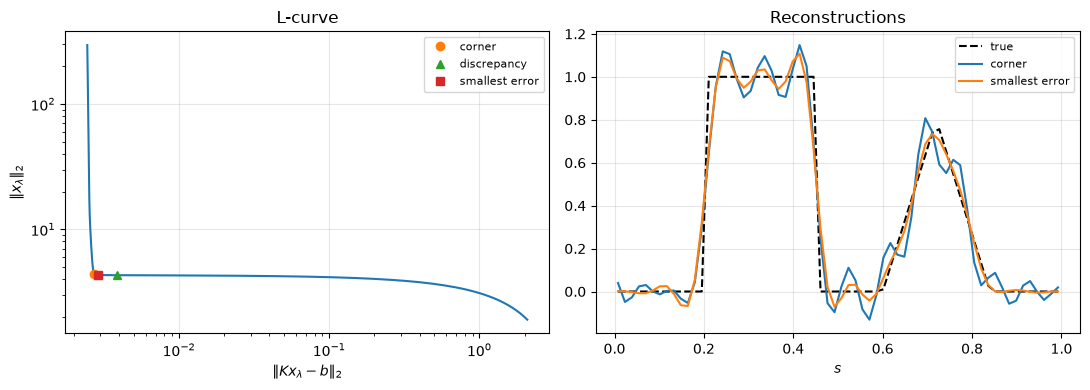

In [18]:
lams = np.logspace(-6, 0, 241)
X = [tikhonov_svd(lam) for lam in lams]
rho = np.array([np.linalg.norm(K @ x - b) for x in X])
nrm = np.array([np.linalg.norm(x) for x in X])
err = np.array([relerr(x) for x in X])

tl, lr, ln_ = np.log(lams), np.log(rho), np.log(nrm)
d1r, d1e = np.gradient(lr, tl), np.gradient(ln_, tl)
d2r, d2e = np.gradient(d1r, tl), np.gradient(d1e, tl)
curvature = (d1r * d2e - d2r * d1e) / (d1r**2 + d1e**2) ** 1.5
i_corner, i_best = int(np.argmax(curvature)), int(np.argmin(err))
i_disc = int(np.argmin(np.abs(rho - np.linalg.norm(e))))
for name, i in (("L-curve corner", i_corner), ("discrepancy principle", i_disc), ("smallest error", i_best)):
    print(f"{name:22s} lambda = {lams[i]:.1e}, relative error {err[i]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(rho, nrm)
for i, mk, name in ((i_corner, "o", "corner"), (i_disc, "^", "discrepancy"), (i_best, "s", "smallest error")):
    axes[0].loglog(rho[i], nrm[i], mk, label=name)
axes[0].set_xlabel(r"$\|Kx_\lambda - b\|_2$")
axes[0].set_ylabel(r"$\|x_\lambda\|_2$")
axes[0].set_title("L-curve")
axes[0].legend(fontsize=8)
axes[1].plot(s_grid, x_true, "k--", label="true")
axes[1].plot(s_grid, X[i_corner], label="corner")
axes[1].plot(s_grid, X[i_best], label="smallest error")
axes[1].set_xlabel("$s$")
axes[1].set_title("Reconstructions")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
assert np.all(np.diff(rho) >= -1e-12 * rho[1:]) and np.all(np.diff(nrm) <= 1e-12 * nrm[1:])   # monotonicity

**Interpretation.** The residual norm increases and the solution norm
decreases monotonically in $\lambda$ ([Theorem 8.6](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-thm-tikhonov)). The
corner of the L-curve and the discrepancy principle both give errors of
roughly $20\%$, not far from the best achievable value of about $16\%$ on this
grid; the naive solution is useless. The remaining error is due to the
blurring, which has destroyed the information carried by the components with
$\sigma_i$ below the noise level; the sharp edges of the box cannot be
recovered.

## 11. A pointer to iterative methods: LSQR

For a large sparse matrix, LSQR (Paige and Saunders, 1982) solves the least-squares
problem using only products with $A$ and $A^T$. It is a Krylov subspace
method; Krylov methods for linear systems are the subject of
[Chapter 11](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11).
Its `damp` argument adds Tikhonov regularization.

In [19]:
m, n = 3000, 300
A_sp = sp.random(m, n, density=0.01, random_state=1, format="csr") + sp.eye(m, n, format="csr")
b = rng.standard_normal(m)
out = spla.lsqr(A_sp, b, atol=1e-12, btol=1e-12, iter_lim=2000)
x_lsqr, istop, itn = out[0], out[1], out[2]
x_dir = ls_householder(A_sp.toarray(), b)
print(f"LSQR: {itn} iterations, relative difference from Householder QR "
      f"{np.linalg.norm(x_lsqr - x_dir) / np.linalg.norm(x_dir):.1e}")
print(f"kappa(A) = {np.linalg.cond(A_sp.toarray()):.1f}")

LSQR: 28 iterations, relative difference from Householder QR 1.0e-11
kappa(A) = 3.2


## Common mistakes

- Measuring the error of a least-squares method against the vector used to
  generate noisy data. Compare with the exact least-squares solution.
- Claiming that the normal equations and QR "respond differently" to a
  perturbation of the data. The exact solution moves the same way; the
  methods differ in the rounding errors they add.
- Computing $\hat Q^Tb$ with a Gram--Schmidt $\hat Q$. Process $b$ as an
  extra column instead.
- Dividing by every computed singular value. Truncate below a tolerance that
  reflects the accuracy of the data.
- Calling a function "Cholesky" when it calls `np.linalg.solve` (LU), or
  "minimum-norm" when it is not: docstrings are part of the code.
- Choosing a regularization parameter by eye on a linear plot; use the
  L-curve on log-log axes or the discrepancy principle.

## Your turn

1. Repeat the experiment of Section 4 with $\tan\theta = 10^{-4}$. For which
   $\kappa$ does the QR error change from the $u\kappa$ to the $u\kappa^2$
   regime? Compare with [(8.11)](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#equation-ch08-eq-qr-forward).
2. In Section 5, choose $x$ parallel to $v_n$ and check that
   $\kappa^2\tan\theta/\eta$ reduces to $\kappa\tan\theta$
   ([Exercise 8.7](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-ex-eta)).
3. Implement least squares with Givens rotations and check its accuracy
   against `ls_householder`.
4. Carry out [Exercise 8.12](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-ex-rank) and [Exercise 8.8](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-ex-mgs).
5. Add $5\%$ noise to the Fredholm problem and compare the parameter choices
   again.

## Key takeaways

- Householder QR (with $Q^Tb$ applied implicitly) and MGS on $[A,\ b]$ are
  backward stable; the normal equations have errors of order $\kappa^2u$.
- For small residuals this makes the normal equations much less accurate; for
  large residuals the problem itself has condition number of order $\kappa^2$
  and all methods are comparable.
- The condition numbers of [Theorem 8.3](https://aalsammani.github.io/numerical-linear-algebra/ch08-least-squares/notes.html#ch08-thm-conditioning) are attained by
  explicit perturbations.
- Rank-deficient problems need a rank decision; Tikhonov regularization with
  a well-chosen $\lambda$ handles problems without a gap.

## Further reading

Trefethen and Bau (1997), Lectures 11, 18 and 19; Higham (2002),
Chapter 20; Björck (1996); Hansen (1998) for regularization and
Hansen (1992) for the L-curve.